In [14]:
import sys
sys.path.append("/project/src")

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from rsfmodel import RandomSurvivalForest
from preprocessing import (
    N_IMPORTANT_FEATURES,
    split_features_target,
    low_missingness_complete_case_analysis,
    decode_preprocessed_feature_name,
    SURVIVAL_EVENT_COL,
    SURVIVAL_TIME_COL,
)

import joblib
import wandb

In [16]:
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive # type: ignore
    drive.mount('/content/drive')
    nacc_data_csv = "/content/drive/MyDrive/bachelor/nacc_data_2025.csv"
else:
    nacc_data_csv = "./data/nacc_data_2025.csv"

In [17]:
nacc_raw = pd.read_csv(nacc_data_csv, delimiter=',')

/tmp/ipykernel_1728/2070981678.py:1: DtypeWarning: Columns (4,8,10,21,25,27,28,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,138,149,190,193,195,201,203,205,207,209,211,215,217,219,221,223,225,227,229,231,233,235,237,239,241,245,370,372,374,405,418,425,465,545,576,601,636,652,669,672,689,700,706,758,760,762,763,769,792,805,813,814,815,816,826,848,851,854) have mixed types. Specify dtype option on import or set low_memory=False.
  nacc_raw = pd.read_csv(nacc_data_csv, delimiter=',')


In [18]:
nacc_raw.head()

,NACCREFR,SEX,HISPANIC,HISPOR,HISPORX,RACE,RACEX,RACESEC,RACESECX,RACETER,...,NPCOTH1,NPOTH1X,NPPOTH2,NPCOTH2,NPOTH2X,NPPOTH3,NPCOTH3,NPOTH3X,EVENT_MCI,TIME
0,1.0,1,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.487
1,NaN,2,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1.035
2,2.0,2,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3.474
3,1.0,2,0.0,NaN,NaN,1.0,NaN,5.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3.025
4,NaN,1,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2.012


In [19]:
print(f"shape {nacc_raw.shape}")

shape (17477, 857)


In [20]:
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive # type: ignore
    drive.mount('/content/drive')
    nacc_preprocessed_train_data_csv = "/content/drive/MyDrive/bachelor/nacc_train_tunning_preprocessed.csv"
    nacc_train_raw_csv = "/content/drive/MyDrive/bachelor/nacc_train.csv"
else:
    nacc_preprocessed_train_data_csv = "./data/nacc_train_tunning_preprocessed.csv"
    nacc_train_raw_csv = "./data/nacc_train.csv"

In [21]:
nacc_preprocessed_train_df = pd.read_csv(nacc_preprocessed_train_data_csv, delimiter=',')
nacc_train_raw = pd.read_csv(nacc_train_raw_csv, delimiter=',')

/tmp/ipykernel_1728/1728453696.py:2: DtypeWarning: Columns (4,10,21,27,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,190,193,205,209,211,215,217,219,221,223,225,227,229,231,233,235,237,239,241,245,370,372,374,394,405,418,465,545,576,601,669,672,706,758,760,763,792,804,805,813,814,815,816,826,851,854) have mixed types. Specify dtype option on import or set low_memory=False.
  nacc_train_raw = pd.read_csv(nacc_train_raw_csv, delimiter=',')


In [22]:
nacc_preprocessed_train_df.shape

(6176, 348)

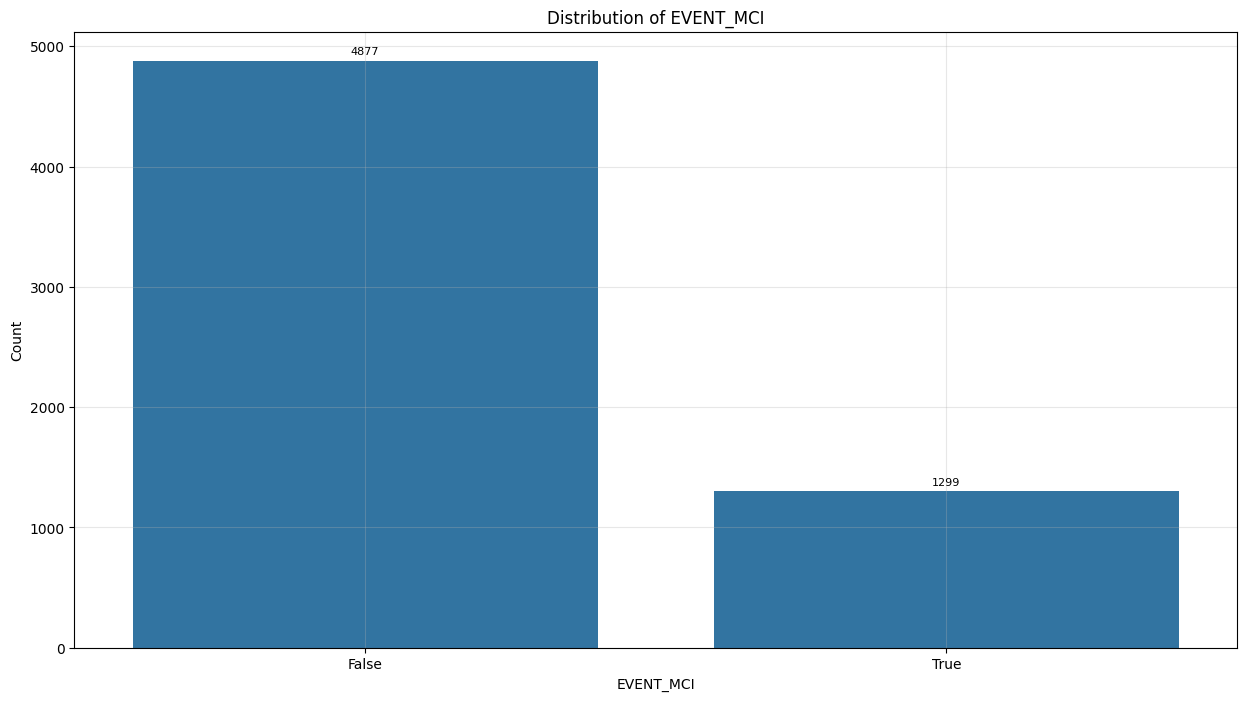

In [23]:
plt.figure(figsize=(15, 8))
bars = sns.barplot(x=nacc_preprocessed_train_df['EVENT_MCI'].value_counts().index, y=nacc_preprocessed_train_df['EVENT_MCI'].value_counts().values)
for bar in bars.containers:
    ax = bars.axes
    ax.bar_label(bar, padding=3, fontsize=8)
plt.title('Distribution of EVENT_MCI')
plt.xlabel('EVENT_MCI')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
nacc_preprocessed_train_df['EVENT_MCI'].value_counts(normalize=True)

EVENT_MCI
False    0.78967
True     0.21033
Name: proportion, dtype: float64

According to EPV rule we need to provide as least 10 records per variable for the analysis and prediction to be reliable. After analysing the number of events during the eda - the number of features cannot extend 237 values (The 1 place is remained for the missing indicator, that should definetelly be in the final dataset)

## Feature selection function

In [25]:
def rsf_vimp_feature_selection(x_data, y_data, n_features, rsf_params):
    rsf = RandomSurvivalForest(
        num_trees       = rsf_params["num_trees"],
        mtry            = rsf_params["mtry"],
        min_node_size   = rsf_params["min_node_size"],
        replace         = rsf_params["replace"],
        sample_fraction = rsf_params["sample_fraction"],
        importance      = "permutation",
        compute_weights = True,
        OOB_score       = True,
    )
    rsf.fit(x_data, y_data)
    vimp_importance = rsf.get_importance()

    print("rsf.oob_score_():", rsf.oob_score_())
    return vimp_importance.head(n_features).index.tolist(), vimp_importance.head(n_features)


# Init wandb

In [26]:
# Start a new wandb run to track this script.
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="semariik",
    # Set the wandb project where this run will be logged.
    project="survival-analysis-mci",
)

wandb: Currently logged in as: mariik04 (semariik) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Fit dataset preprocessor on train data

In [27]:
best_parameters = joblib.load("joblib-storage/rsf_vimp_best_params_processed.joblib")

In [28]:
best_parameters

{'num_trees': np.int64(200),
 'mtry': 'sqrt',
 'min_node_size': 51,
 'replace': True,
 'sample_fraction': np.float64(0.567689423343695)}

In [29]:
X_train_base_preprocessed, y_train_base_preprocessed = split_features_target(nacc_preprocessed_train_df)

In [30]:
selected_features_columns, selected_features_df = rsf_vimp_feature_selection(
    X_train_base_preprocessed, y_train_base_preprocessed, n_features=N_IMPORTANT_FEATURES, rsf_params=best_parameters
)

R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :  
R callback write-console: 
   
R callback write-console:  library ‘/usr/lib/R/site-library’ contains no packages
  



Running Random Survival Forest with parameters: num_trees=200, min_node_size=51, mtry=sqrt, splitrule='C', importance='permutation', compute_weights=True, replace=True, sample_fraction=0.567689423343695
Growing trees.. Progress: 16%. Estimated remaining time: 2 minutes, 49 seconds.
Growing trees.. Progress: 32%. Estimated remaining time: 2 minutes, 13 seconds.
Growing trees.. Progress: 51%. Estimated remaining time: 1 minute, 31 seconds.
Growing trees.. Progress: 70%. Estimated remaining time: 55 seconds.
Growing trees.. Progress: 89%. Estimated remaining time: 19 seconds.
Computing permutation importance.. Progress: 17%. Estimated remaining time: 2 minutes, 52 seconds.
Computing permutation importance.. Progress: 37%. Estimated remaining time: 1 minute, 58 seconds.
Computing permutation importance.. Progress: 56%. Estimated remaining time: 1 minute, 19 seconds.
Computing permutation importance.. Progress: 76%. Estimated remaining time: 42 seconds.
Computing permutation importance.. P

In [31]:
selected_features_df

,importances_mean,importances_mean_abs
continuous__TRAILB,0.017027,0.017027
continuous__NACCAGEB,0.015256,0.015256
categorical__NACCNOVS_0,0.012841,0.012841
categorical__NACCNOVS_1,0.010362,0.010362
continuous__VEG,0.010115,0.010115
...,...,...
categorical__INDEPEND_1.0,0.000013,0.000013
categorical__NACCAAAS_0.0,0.000013,0.000013
categorical__NORMEXAM_2.0,-0.000012,0.000012
categorical__HYPERTEN_HYPERTEN_2.0,0.000012,0.000012


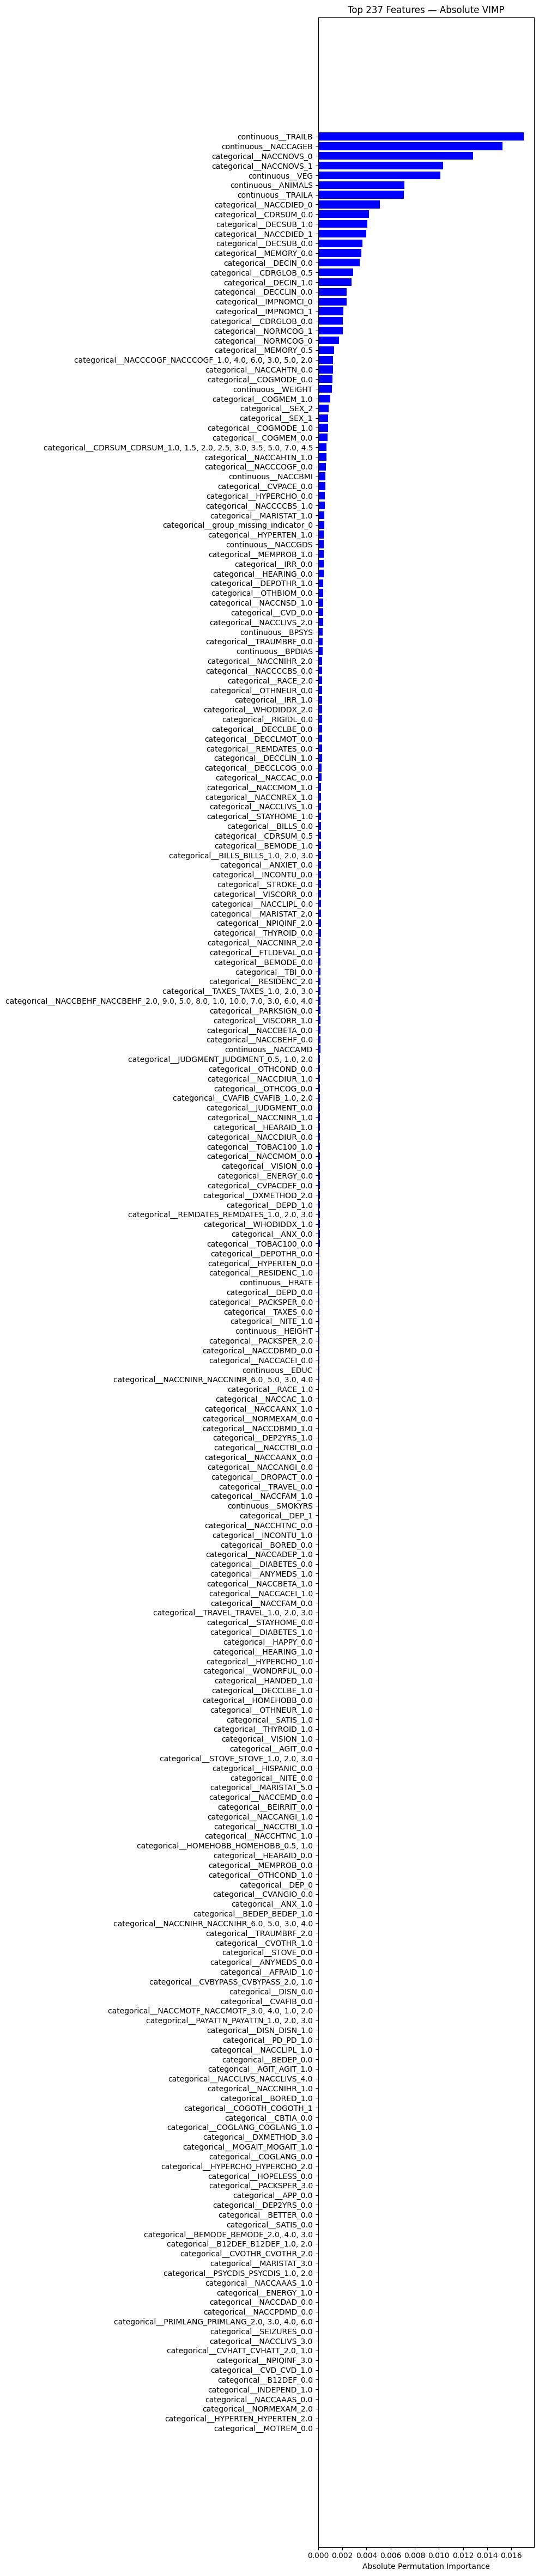

In [32]:
fig_abs, ax_abs = plt.subplots(figsize=(10, max(6, len(selected_features_df) * 0.2)))
sorted_abs = selected_features_df.sort_values("importances_mean_abs", ascending=True)
ax_abs.barh(sorted_abs.index, sorted_abs["importances_mean_abs"], color="blue")
ax_abs.set_xlabel("Absolute Permutation Importance")
ax_abs.set_title(f"Top {len(selected_features_df)} Features — Absolute VIMP")
plt.tight_layout()
plt.show()

In [33]:
wandb.log({"vimp/absolute_importance": wandb.Image(fig_abs)})

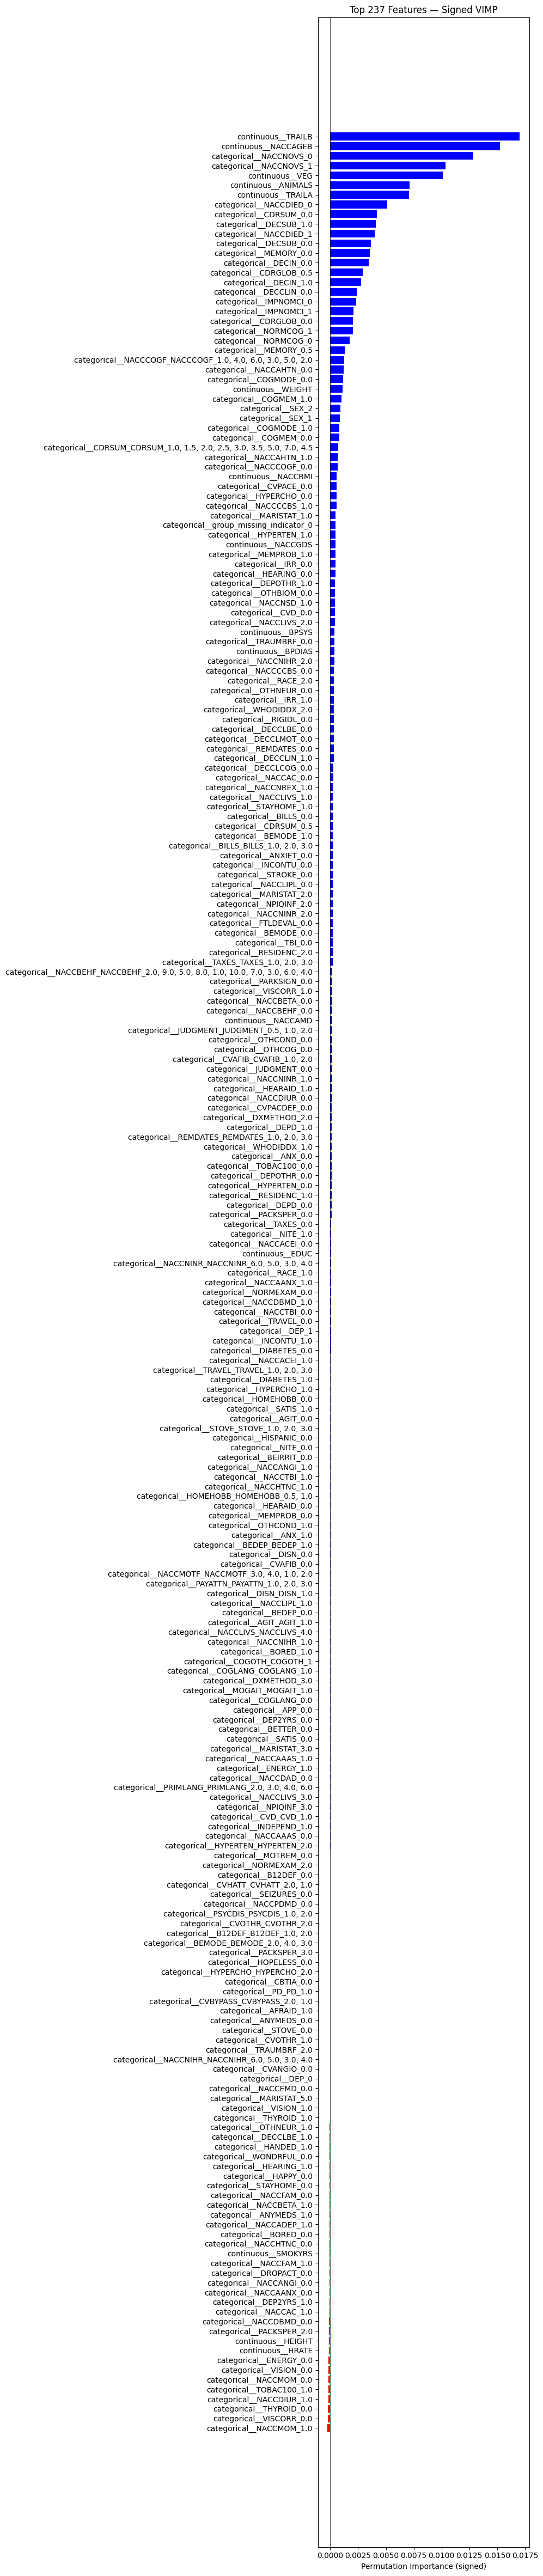

In [34]:
fig_signed, ax_signed = plt.subplots(figsize=(10, max(6, len(selected_features_df) * 0.2)))
sorted_signed = selected_features_df.sort_values("importances_mean", ascending=True)
colors = ["red" if v < 0 else "blue" for v in sorted_signed["importances_mean"]]
ax_signed.barh(sorted_signed.index, sorted_signed["importances_mean"], color=colors)
ax_signed.axvline(x=0, color="black", linewidth=0.5)
ax_signed.set_xlabel("Permutation Importance (signed)")
ax_signed.set_title(f"Top {len(selected_features_df)} Features — Signed VIMP")
plt.tight_layout()
plt.show()

In [35]:
wandb.log({"vimp/signed_importance": wandb.Image(fig_signed)})

In [36]:
# Decode preprocessed feature names (e.g. 'continuous__HRATE') back to raw column names
# Use nacc_raw columns as the reference for matching
raw_columns = nacc_raw.columns.tolist()
raw_feature_names = list(set(
    decode_preprocessed_feature_name(f, raw_columns, raw_columns)
    for f in selected_features_columns
))

# Select only the raw features + target, then complete case analysis on each split
target_cols = [SURVIVAL_EVENT_COL, SURVIVAL_TIME_COL]
available_raw_features = [c for c in raw_feature_names if c in nacc_raw.columns]

reduced_train = nacc_train_raw[available_raw_features + target_cols]
train_df_reduced = low_missingness_complete_case_analysis(reduced_train)

Complete-case analysis on low-missing columns
Defining missingness


In [37]:
X_train_reduced, y_train_reduced = split_features_target(train_df_reduced)

In [38]:
train_df_reduced.to_csv("./data/nacc_train_reduced.csv", index=False)

# Asses final data

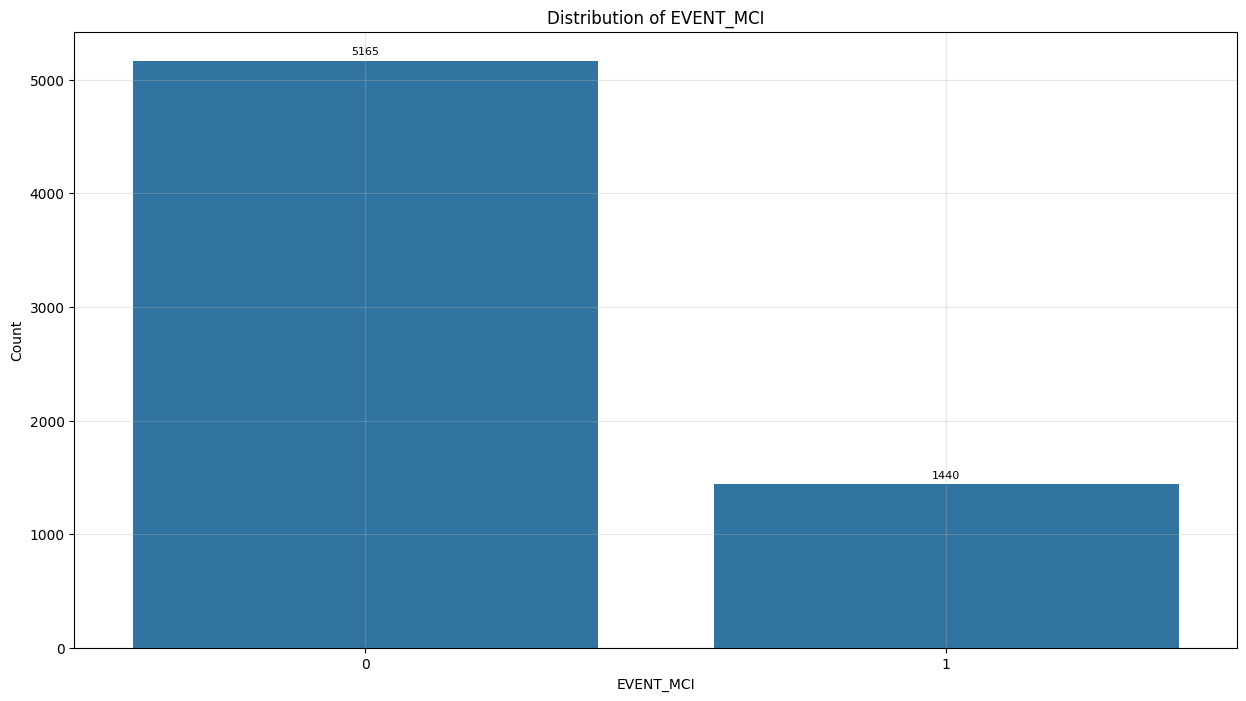

In [39]:
plt.figure(figsize=(15, 8))
bars = sns.barplot(x=train_df_reduced['EVENT_MCI'].value_counts().index, y=train_df_reduced['EVENT_MCI'].value_counts().values)
for bar in bars.containers:
    ax = bars.axes
    ax.bar_label(bar, padding=3, fontsize=8)
plt.title('Distribution of EVENT_MCI')
plt.xlabel('EVENT_MCI')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

In [40]:
train_df_reduced['EVENT_MCI'].value_counts(normalize=True)

EVENT_MCI
0    0.781983
1    0.218017
Name: proportion, dtype: float64

In [41]:
train_df_reduced.shape

(6605, 143)

In [42]:
wandb.finish()